In [ ]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import pywt
import matplotlib.pyplot as plt

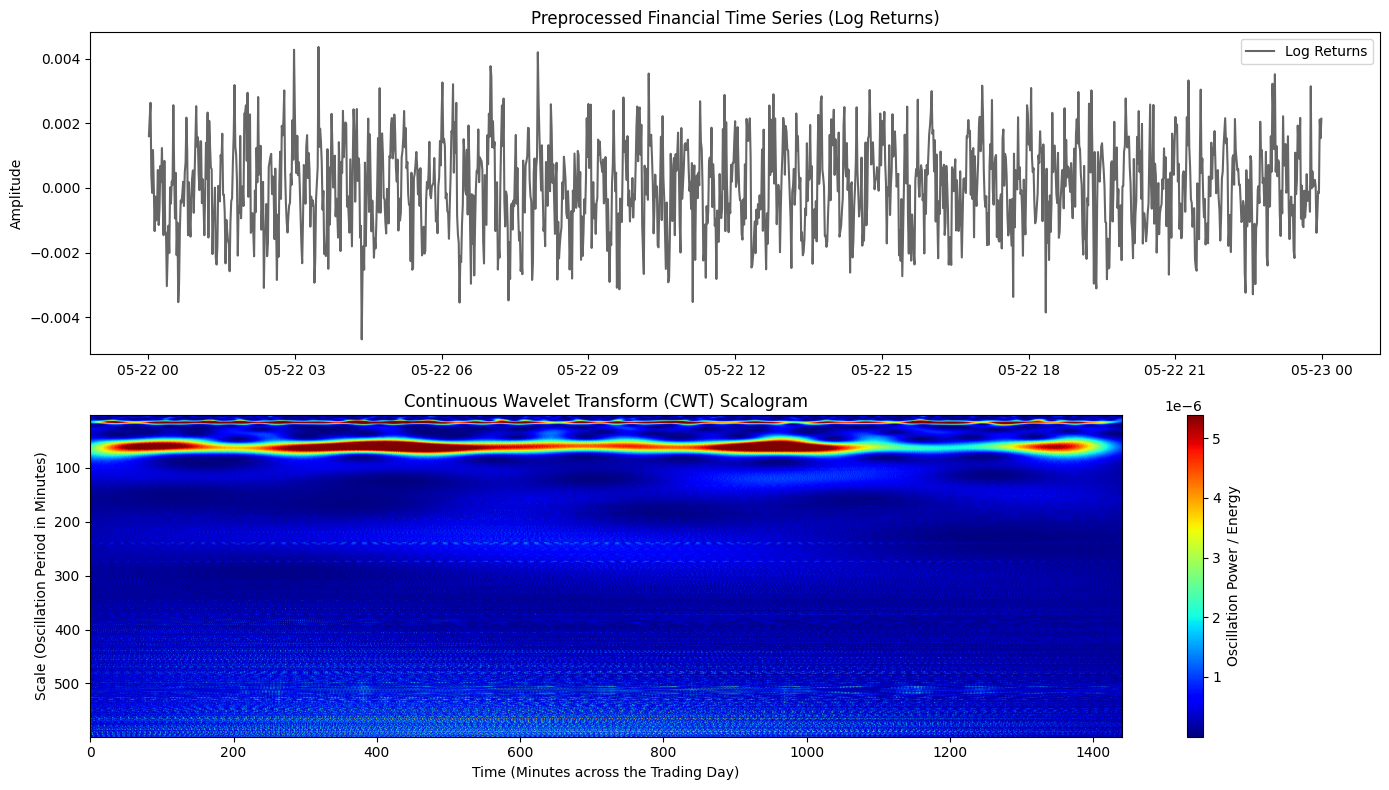

In [ ]:
def subhournoise(df=None,len_to_analyze=1440):
    # ---------------------------------------------------------
    # 1. SETUP & SIMULATED DATA GENERATION
    # ---------------------------------------------------------
    # Simulating 1-minute interval data for a crypto asset (24 hours = 1440 minutes)
    if df is None:
        np.random.seed(42)
        time = np.arange(0, 1440)
        base_trend = np.cumsum(np.random.normal(0, 0.1, size=1440)) + 100

        # Injecting artificial 15-minute and 60-minute cyclical noises (the "artifacts")
        artifact_15min = 0.3 * np.sin(2 * np.pi * time / 15)
        artifact_60min = 0.5 * np.sin(2 * np.pi * time / 60)
        raw_price = base_trend + artifact_15min + artifact_60min

        df = pd.DataFrame({'price': raw_price}, index=pd.date_range("2026-05-22", periods=1440, freq='min'))
    else:
        #sandp data
        df.index = pd.date_range("1997-05-01", periods=len(df), freq='2min')
    # ---------------------------------------------------------
    # 2. SCIENTIFIC PREPROCESSING FOR CWT
    # ---------------------------------------------------------
    # Rule: CWT requires stationary data. Raw prices cause boundary distortions (edge effects).
    # We calculate log returns to stabilize the mean and variance.
    df['log_return'] = np.log(df['price'] / df['price'].shift(1))
    df.dropna(inplace=True)

    signal_to_analyze = df['log_return'].values[:len_to_analyze]

    # ---------------------------------------------------------
    # 3. CONTINUOUS WAVELET TRANSFORM (CWT)
    # ---------------------------------------------------------
    # Define the widths (scales) to analyze. 
    # For a 1-minute sampling rate, scales roughly map to minute frequencies.
    # We look at cycles from 2 minutes up to 120 minutes.
    widths = np.arange(2, 600)

    # Execute CWT using the scientifically preferred Complex Morlet Wavelet
    # 'cmor1.5-1.0' means: bandwidth parameter = 1.5, center frequency = 1.0
    #cwt_matrix, frequencies = signal.cwt(signal_to_analyze, signal.cmorlet, widths)

    cwt_matrix, frequencies = pywt.cwt(signal_to_analyze, widths, "cmor1.5-1.0")

    # Calculate power spectrum (magnitude squared of complex coefficients)
    power = np.abs(cwt_matrix)**2

    # ---------------------------------------------------------
    # 4. REMOVING / FILTERING THE EFFECTS
    # ---------------------------------------------------------
    # To scientifically remove the effects, zero out coefficients at target scales.
    # Scale 15 corresponds to the 15-minute artifact window.
    filtered_cwt_matrix = cwt_matrix.copy()
    # Zero out scales between 13 and 17 to erase the 15-minute loop
    filtered_cwt_matrix[13:17, :] = 0 

    # ---------------------------------------------------------
    # 5. VISUALIZATION OF TIME-FREQUENCY OSCILLATIONS
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 8))

    # Plot 1: Raw Signal Log Returns
    plt.subplot(2, 1, 1)
    plt.plot(df.index.values[:len_to_analyze], signal_to_analyze, color='black', alpha=0.6, label='Log Returns')
    plt.title('Preprocessed Financial Time Series (Log Returns)')
    plt.ylabel('Amplitude')
    plt.legend()

    # Plot 2: CWT Scalogram (Time-Frequency Domain)
    plt.subplot(2, 1, 2)
    plt.imshow(power, extent=[0, len_to_analyze, widths[-1], widths[0]], cmap='jet', aspect='auto',
               vmax=np.percentile(power, 99)) # Cap scale at 99th percentile to pop out signals
    plt.title('Continuous Wavelet Transform (CWT) Scalogram')
    plt.ylabel('Scale (Oscillation Period in Minutes)')
    plt.xlabel('Time (Minutes across the Trading Day)')
    plt.colorbar(label='Oscillation Power / Energy')

    plt.tight_layout()
    plt.show()
subhournoise()

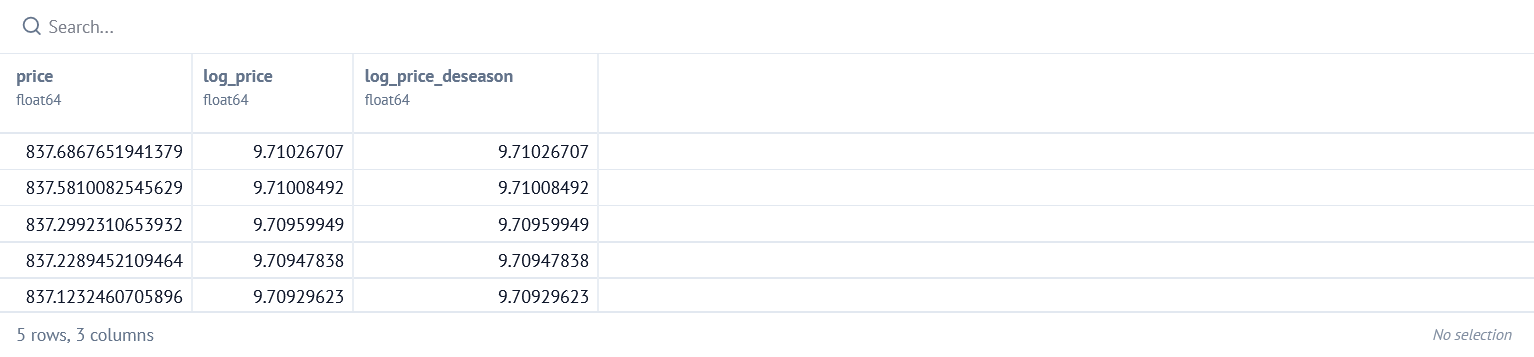

In [ ]:
def get_sandp_data():
    DATA_PATH = "SandP_log2min.dat"   # one value per row

    # Try reading with header; if no header, fallback
    try:
        df = pd.read_csv(DATA_PATH)
        if df.shape[1] == 1:
            df.columns = ['price']
    except:
        df = pd.read_csv(DATA_PATH, header=None)
        df.columns = ['price']

    df = df.dropna().reset_index(drop=True)

    # Log-price
    df['log_price'] = df["price"]
    df['price'] = np.exp2(df['price'])

    # Since there is no intraday pattern, we skip deseasonalization
    df['log_price_deseason'] = df['log_price']

    df.head()
    return df
df_sandp = get_sandp_data()
df_sandp.head()

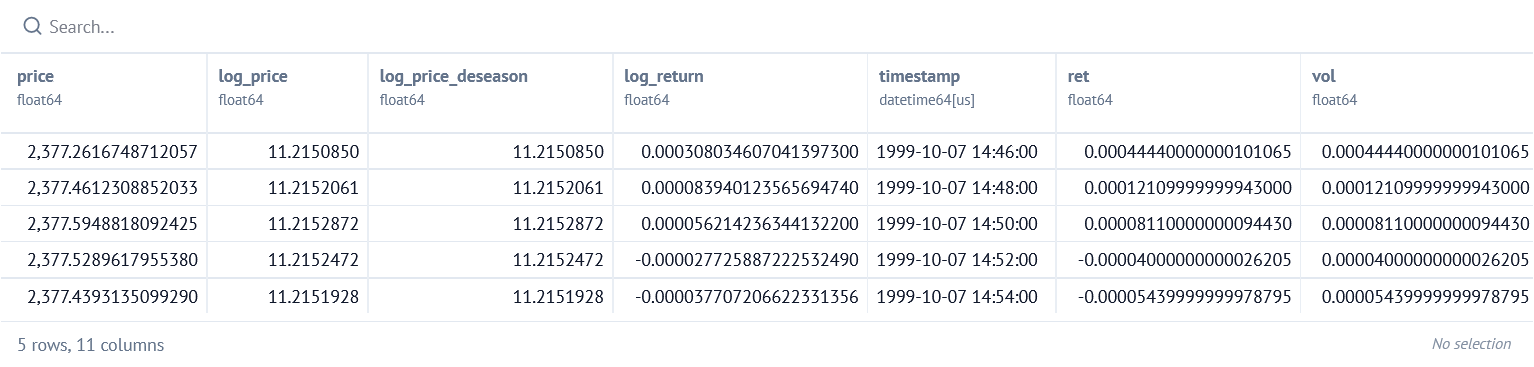

In [ ]:
df_sandp.tail()

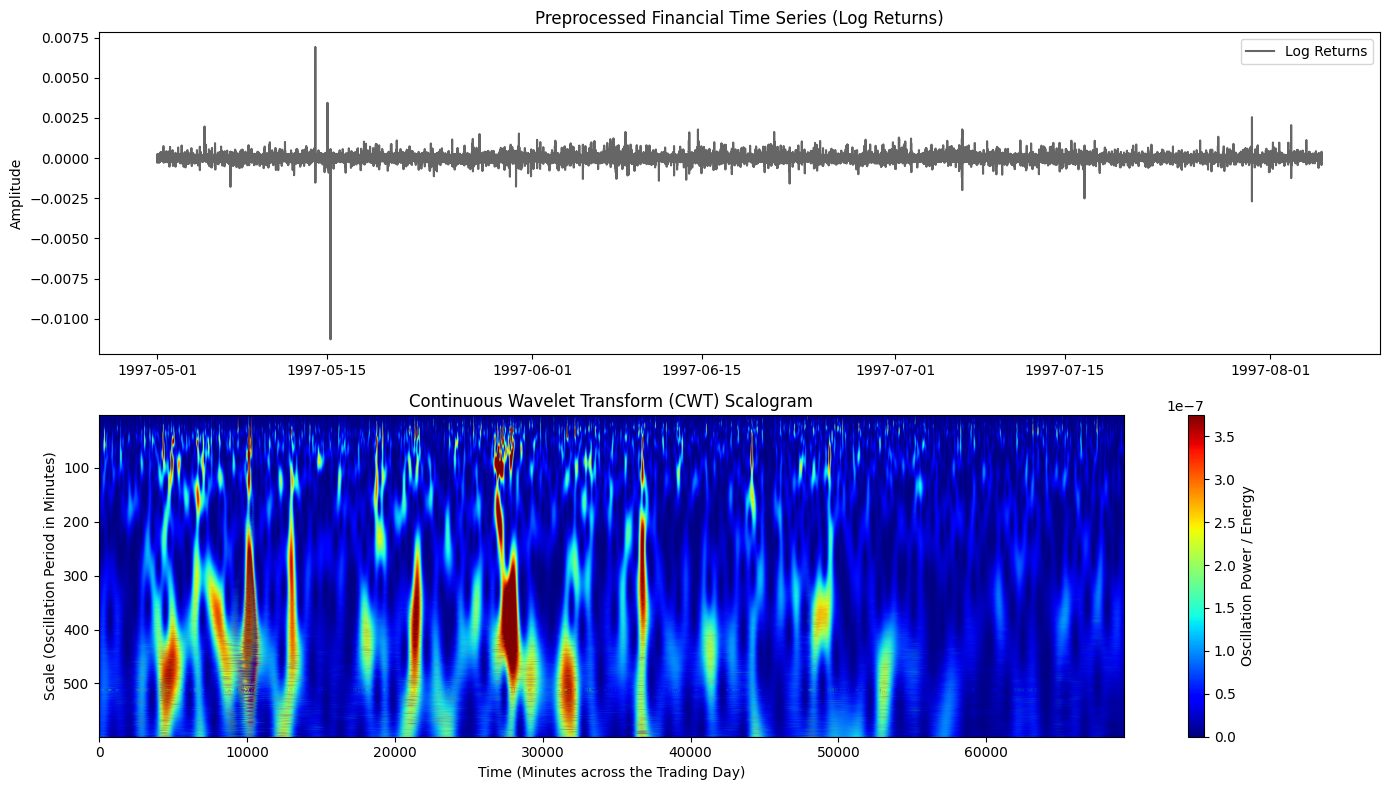

In [ ]:
subhournoise(df_sandp,len_to_analyze=770*90)

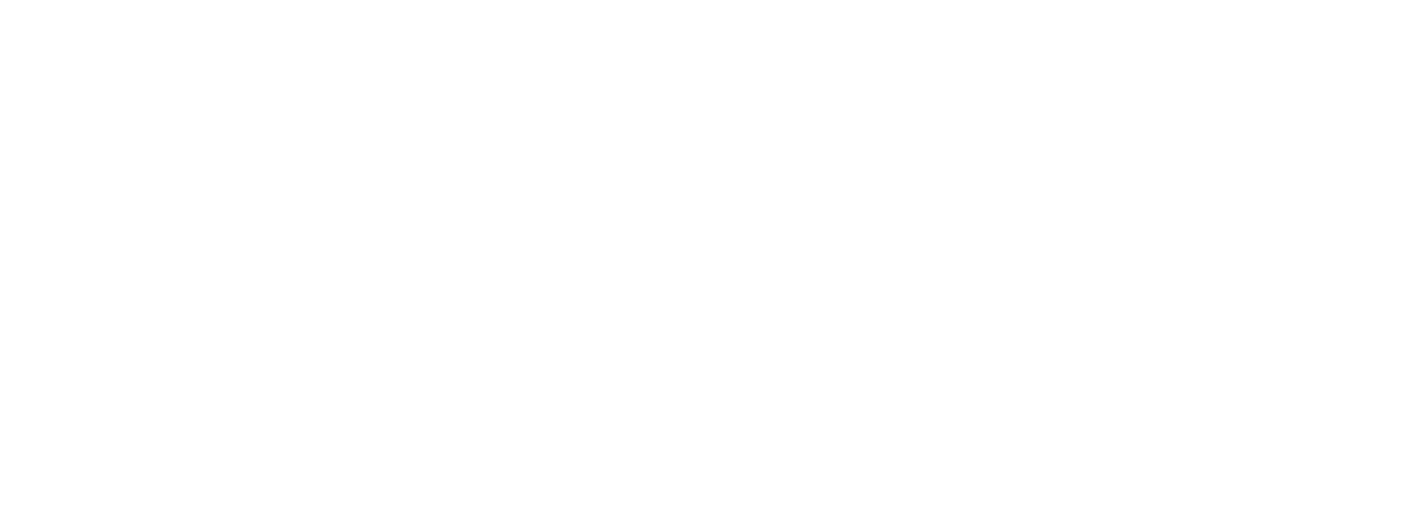

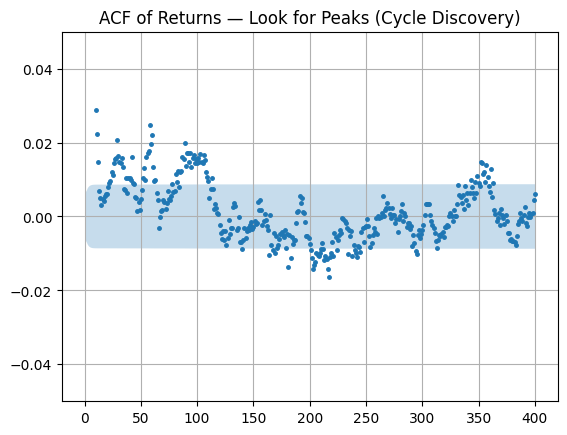

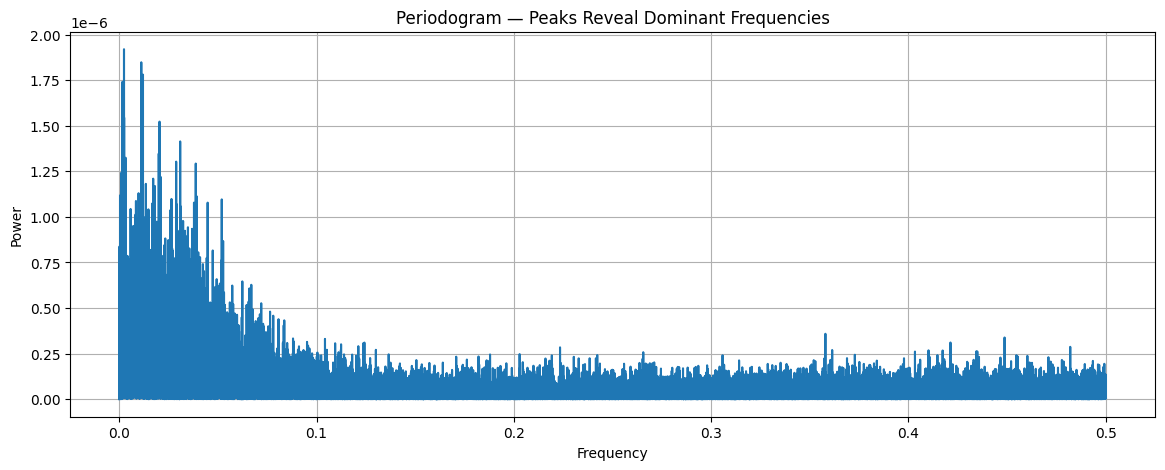

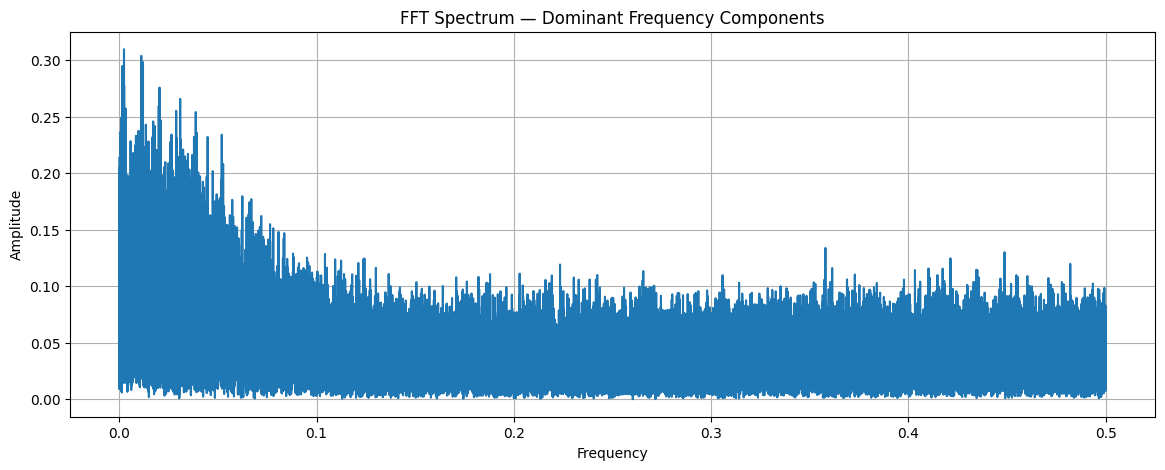

Dominant period detected by FFT: 423.728813559322


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy.signal import periodogram
from numpy.fft import rfft, rfftfreq

def find_seasonality(df,length=10000):
    df['log_return'] = np.log(df['price'] / df['price'].shift(1))
    df.dropna(inplace=True)
    # Use returns for seasonality detection (prices have no seasonality)
    x = df['log_return'].dropna().values[:length]

    # -----------------------------
    # 1. Autocorrelation (ACF)
    # -----------------------------
    plt.figure(figsize=(14,5))
    plot_acf(x, lags=400,alpha=0.05,use_vlines=False,fft=True,marker='.')
    plt.title("ACF of Returns — Look for Peaks (Cycle Discovery)")
    plt.ylim([-0.05,0.05])
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 2. Periodogram (Spectral Density)
    # -----------------------------
    f, Pxx = periodogram(x)

    plt.figure(figsize=(14,5))
    plt.plot(f, Pxx)
    plt.title("Periodogram — Peaks Reveal Dominant Frequencies")
    plt.xlabel("Frequency")
    plt.ylabel("Power")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 3. FFT (Fast Fourier Transform)
    # -----------------------------
    N = len(x)
    freqs = rfftfreq(N, d=1)      # d=1 because index is unit-spaced
    fft_vals = np.abs(rfft(x))

    plt.figure(figsize=(14,5))
    plt.plot(freqs, fft_vals)
    plt.title("FFT Spectrum — Dominant Frequency Components")
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    # Print the dominant period (excluding zero frequency)
    dominant_freq = freqs[np.argmax(fft_vals[1:]) + 1]
    dominant_period = 1 / dominant_freq
    print("Dominant period detected by FFT:", dominant_period)
find_seasonality(df_sandp,100000)

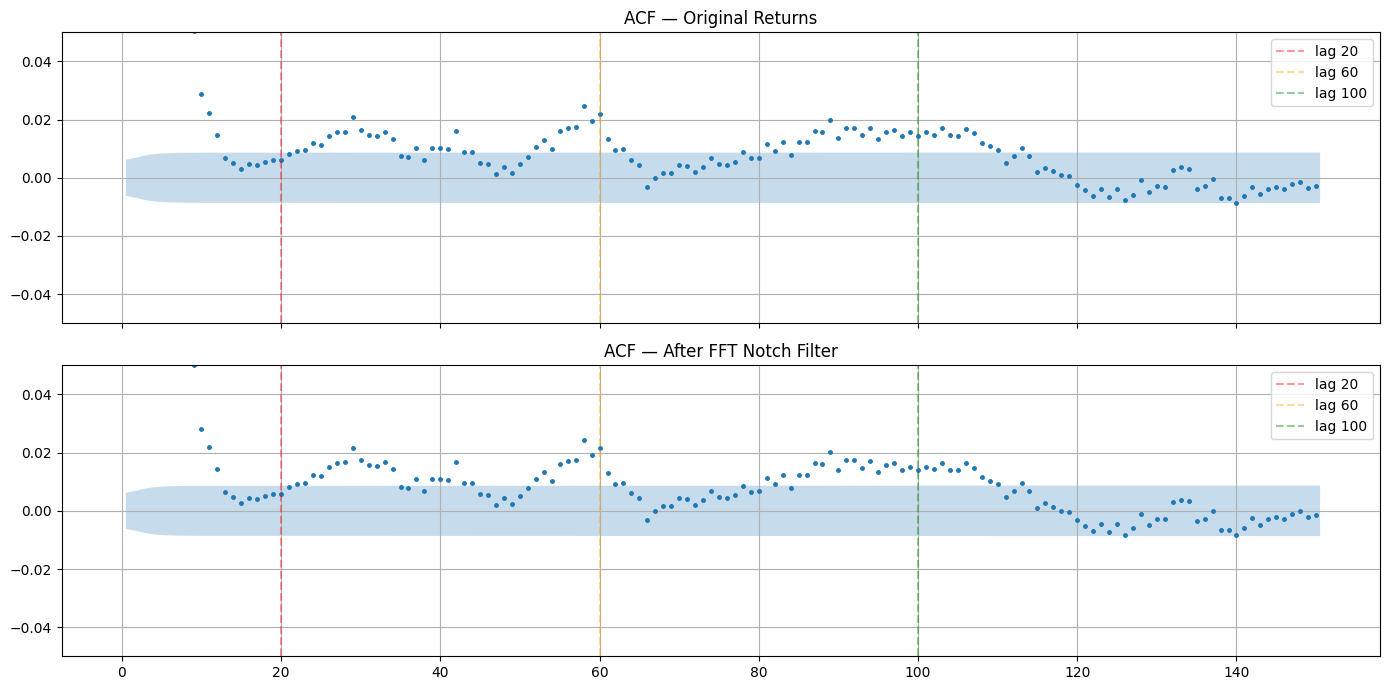

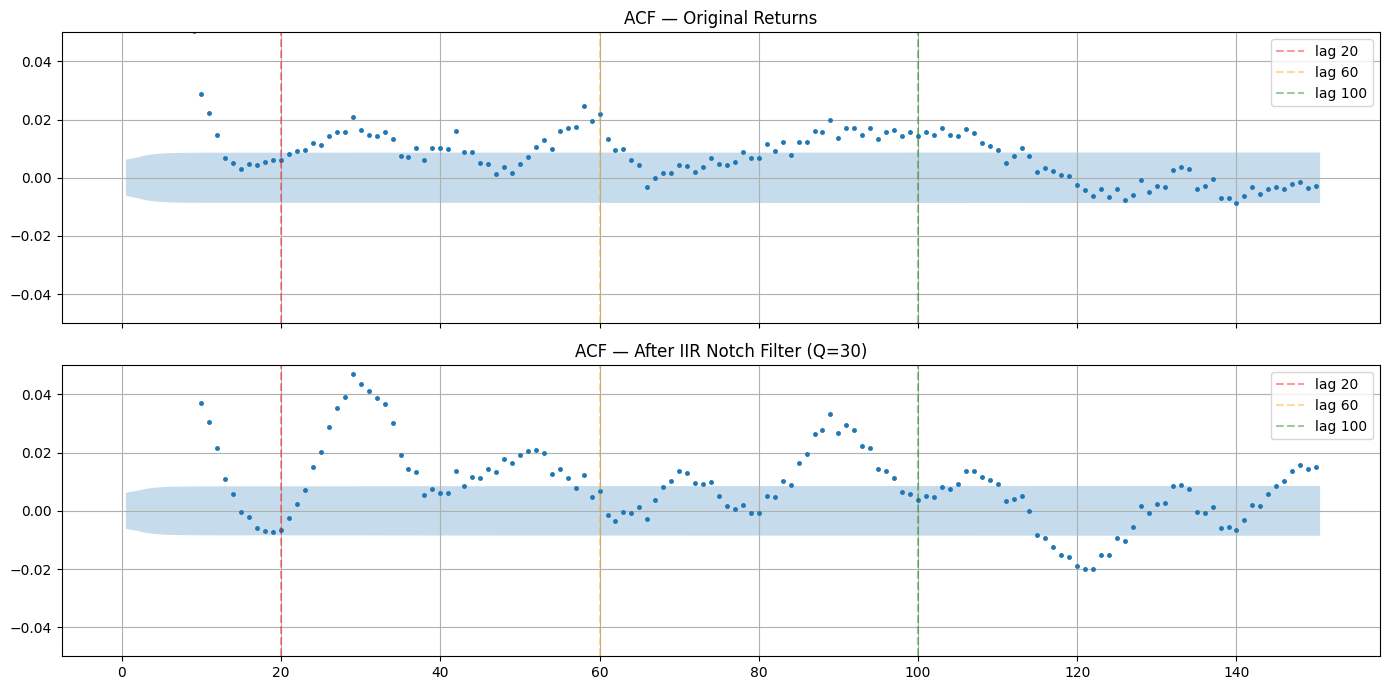

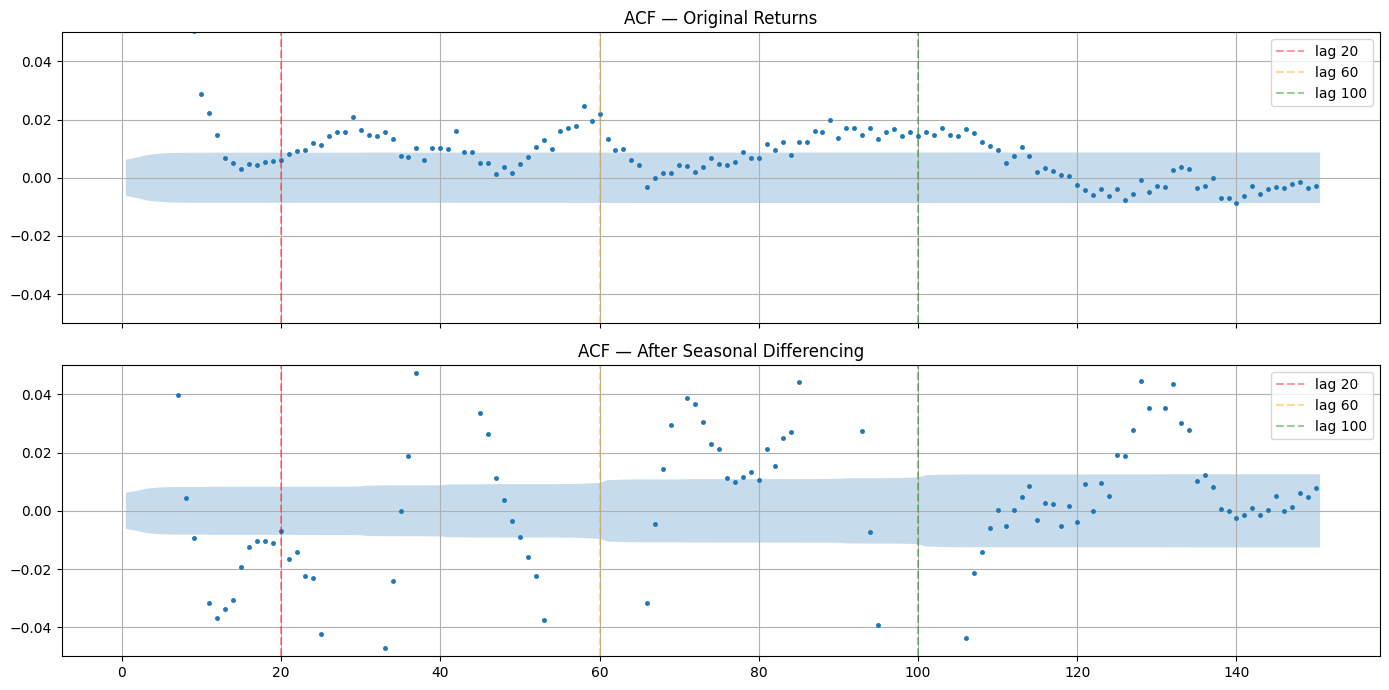

ValueError: Length of values (100000) does not match length of index (640507)

In [ ]:
from scipy.signal import iirnotch, filtfilt
from numpy.fft import irfft
# ─────────────────────────────────────────────
# Helper: plot ACF before/after
# ─────────────────────────────────────────────
def compare_acf(original, filtered, label, lags=150):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    plot_acf(original, lags=lags, ax=axes[0], alpha=0.05, fft=True,
             use_vlines=False, marker='.', title="ACF — Original Returns")
    plot_acf(filtered, lags=lags, ax=axes[1], alpha=0.05, fft=True,
             use_vlines=False, marker='.', title=f"ACF — After {label}")
    for ax in axes:
        ax.set_ylim([-0.05, 0.05])
        ax.axvline(20,  color='red',    linestyle='--', alpha=0.4, label='lag 20')
        ax.axvline(60,  color='orange', linestyle='--', alpha=0.4, label='lag 60')
        ax.axvline(100, color='green',  linestyle='--', alpha=0.4, label='lag 100')
        ax.legend(loc='upper right')
        ax.grid(True)
    plt.tight_layout()
    plt.show()

length=100000
# ─────────────────────────────────────────────
# Prepare returns
# ─────────────────────────────────────────────
df = df_sandp.copy()
df['log_return'] = np.log(df['price'] / df['price'].shift(1))
df.dropna(inplace=True)
x = df['log_return'].values[:100000]  # raw log-returns


# ══════════════════════════════════════════════
# METHOD 1: FFT Notch — zero out target frequencies
# ══════════════════════════════════════════════
def fft_notch_filter(signal, periods, bandwidth=2):
    """
    Zero out FFT bins corresponding to given periods (and harmonics optional).
    bandwidth: number of bins to zero on each side of the peak.
    """
    N = len(signal)
    freqs = rfftfreq(N, d=1)
    fft_vals = rfft(signal)

    target_freqs = [1.0 / p for p in periods]

    for f_target in target_freqs:
        # Find the bin closest to the target frequency
        idx = np.argmin(np.abs(freqs - f_target))
        lo = max(0, idx - bandwidth)
        hi = min(len(fft_vals), idx + bandwidth + 1)
        fft_vals[lo:hi] = 0   # surgical removal

    return irfft(fft_vals, n=N)


x_fft_filtered = fft_notch_filter(x, periods=[20, 60, 100], bandwidth=2)
compare_acf(x, x_fft_filtered, "FFT Notch Filter")


# ══════════════════════════════════════════════
# METHOD 2: IIR Notch Filter (scipy) — causal, real-world friendly
# ══════════════════════════════════════════════
def iir_notch_filter(signal, periods, fs=1.0, quality_factor=30):
    """
    Apply a cascade of IIR notch filters.
    quality_factor: higher Q = narrower notch (more surgical).
    fs=1.0 since time step is 1 unit.
    """
    filtered = signal.copy()
    for period in periods:
        f0 = fs / period          # notch frequency in Hz (normalized to fs)
        w0 = f0 / (fs / 2)        # normalized to Nyquist [0, 1]
        b, a = iirnotch(w0, quality_factor)
        filtered = filtfilt(b, a, filtered)   # zero-phase filtering
    return filtered


x_iir_filtered = iir_notch_filter(x, periods=[20, 60, 100], quality_factor=30)
compare_acf(x, x_iir_filtered, "IIR Notch Filter (Q=30)")


# ══════════════════════════════════════════════
# METHOD 3: Seasonal Differencing (simple baseline)
# ══════════════════════════════════════════════
def seasonal_diff(signal, lags=[20, 60, 100]):
    """
    Sequentially apply seasonal differencing for each lag.
    Note: each differencing shortens the series by `lag` steps.
    """
    s = signal.copy()
    for lag in sorted(lags):
        s = s[lag:] - s[:-lag]
    return s


x_diff_filtered = seasonal_diff(x, lags=[30, 60, 100])
compare_acf(x[180:], x_diff_filtered, "Seasonal Differencing")  # align lengths


# ══════════════════════════════════════════════
# Save the best result back to dataframe
# ══════════════════════════════════════════════
# IIR is usually the best choice for financial data:
df_filtered = df.iloc[:].copy()
df_filtered['log_return_filtered'] = x_iir_filtered

print("Original  std:", np.std(x))
print("Filtered  std:", np.std(x_iir_filtered))
print("Correlation with original:", np.corrcoef(x, x_iir_filtered)[0, 1])

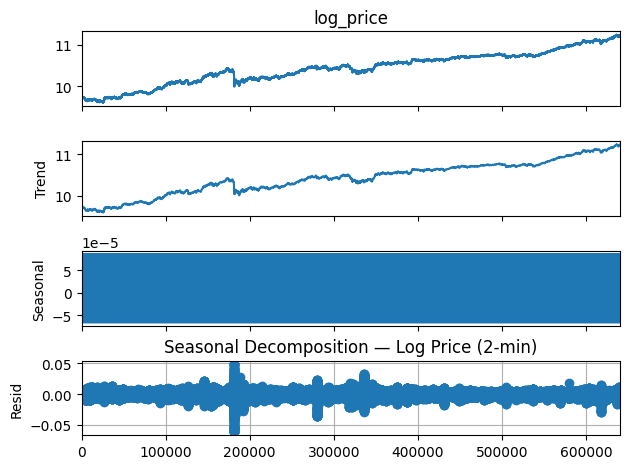

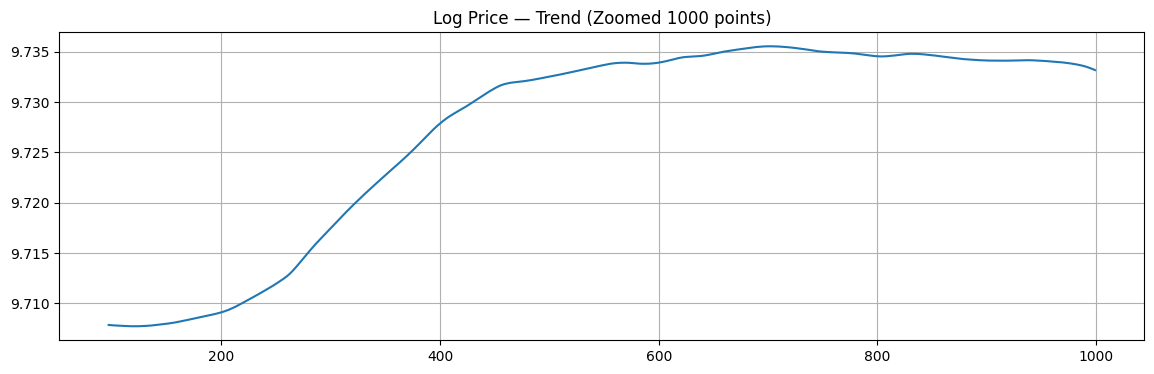

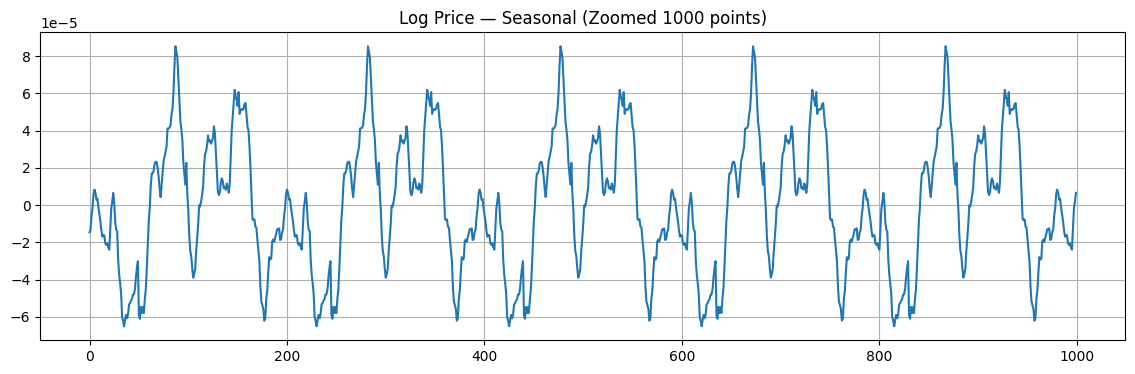

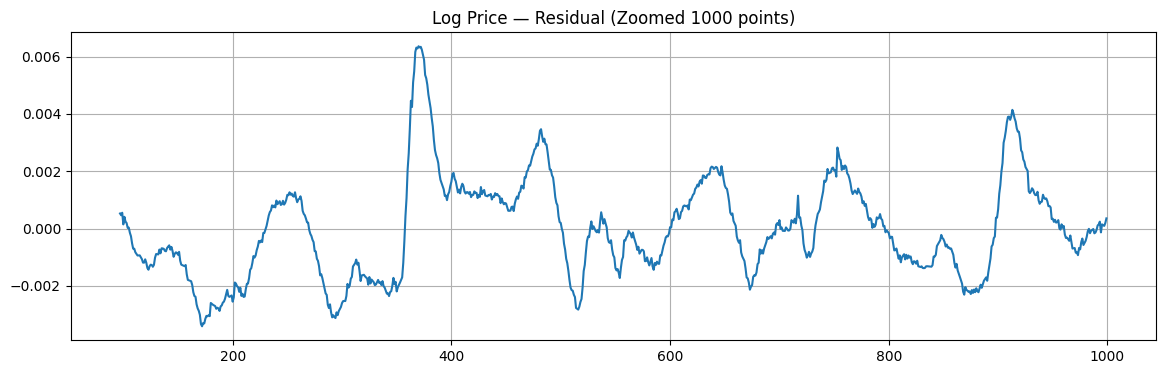

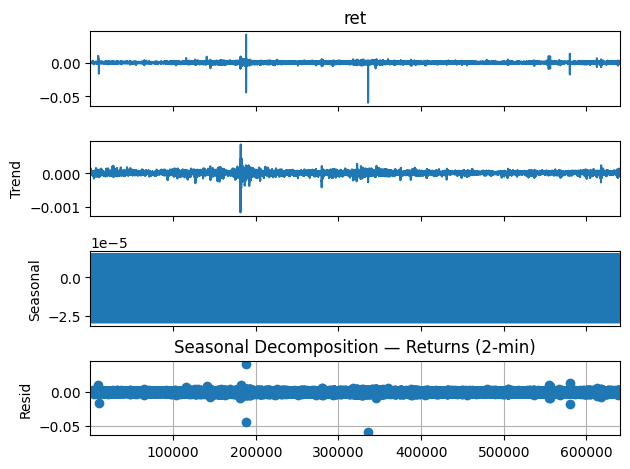

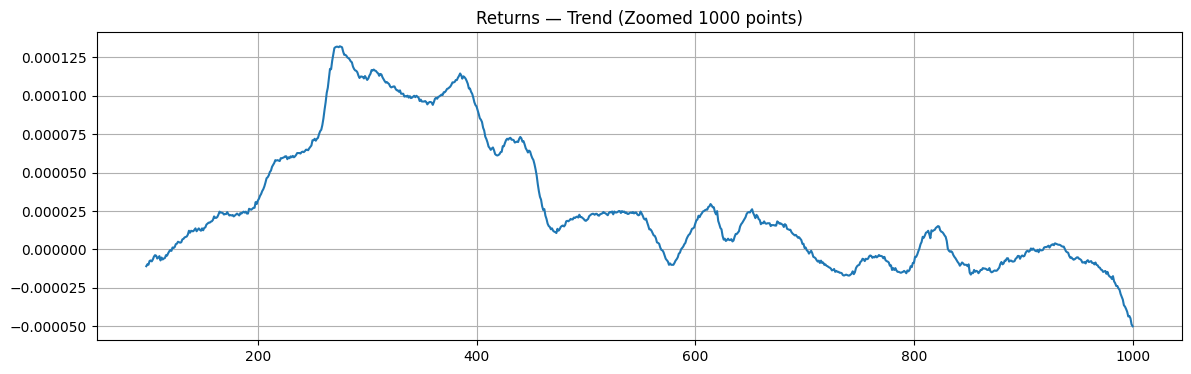

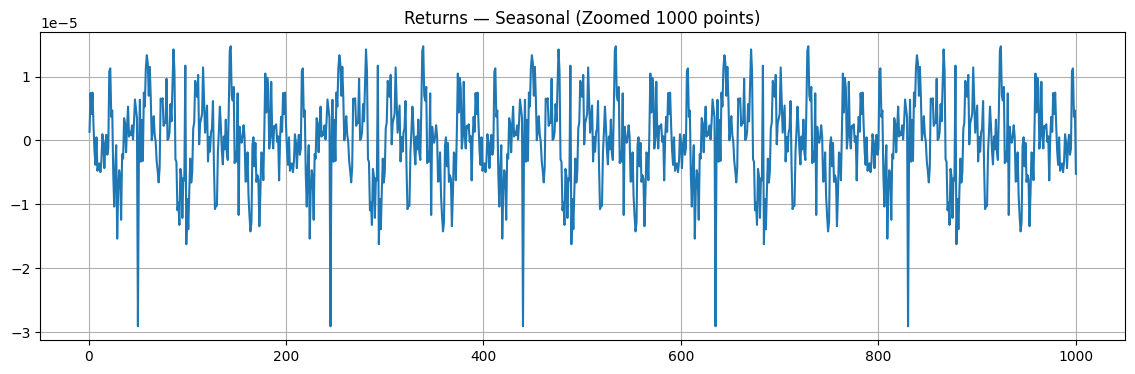

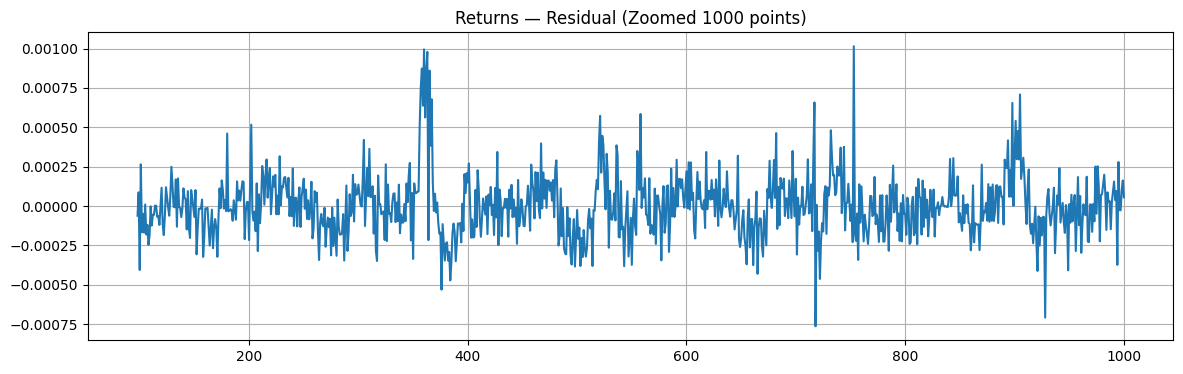

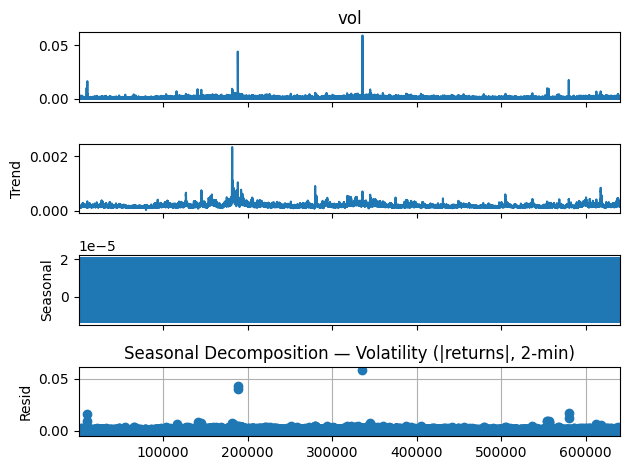

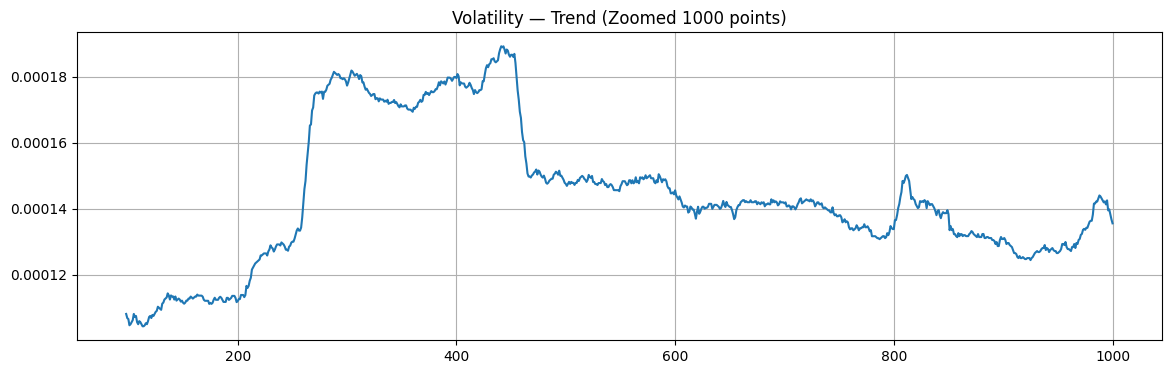

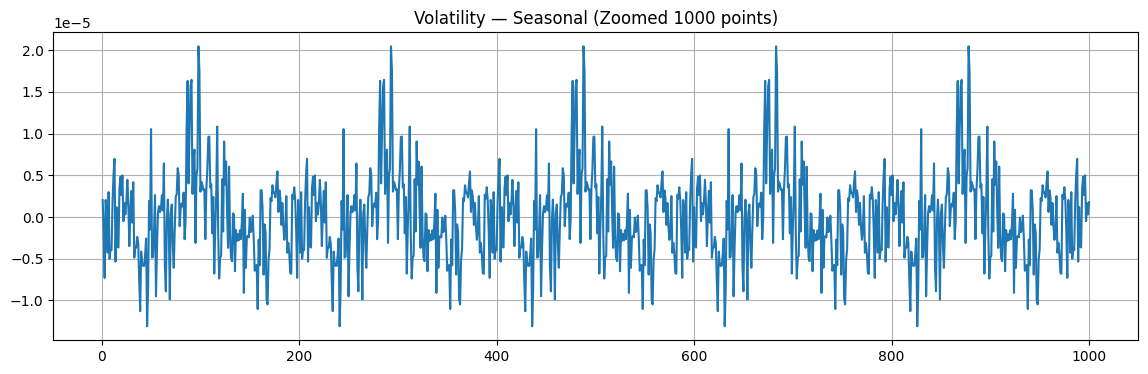

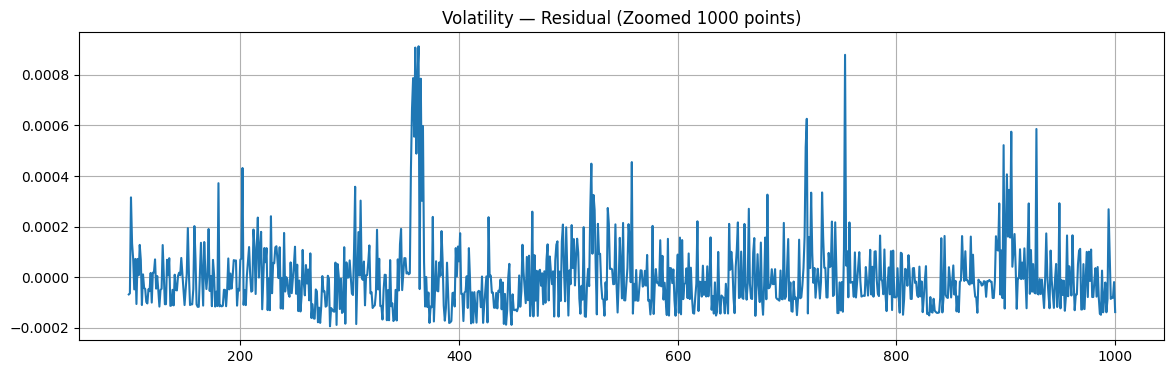

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
#https://pub.towardsai.net/statistical-modeling-of-time-series-data-part-2-exploratory-data-analysis-5c3aaedc04b7
def plot_zoomed_component(result, title_prefix, period=195, zoom_n=500):
    """
    result: seasonal_decompose result object
    title_prefix: e.g. "Price", "Returns", "Volatility"
    period: intraday period (195 for 2-min bars)
    zoom_n: number of points to zoom into for trend/residual
    """

    # --- Trend zoom ---
    plt.figure(figsize=(14, 4))
    plt.plot(result.trend[:zoom_n])
    plt.title(f"{title_prefix} — Trend (Zoomed {zoom_n} points)")
    plt.grid(True)
    plt.show()

    # --- Seasonal zoom (one intraday cycle) ---
    plt.figure(figsize=(14, 4))
    plt.plot(result.seasonal[:zoom_n])
    plt.title(f"{title_prefix} — Seasonal (Zoomed {zoom_n} points)")
    plt.grid(True)
    plt.show()

    # --- Residual zoom ---
    plt.figure(figsize=(14, 4))
    plt.plot(result.resid[:zoom_n])
    plt.title(f"{title_prefix} — Residual (Zoomed {zoom_n} points)")
    plt.grid(True)
    plt.show()


# -----------------------------
# Apply zoomed plotting
# -----------------------------

def seasonal_decompose_sandp(df=df_sandp,model="additive"):
    # df['timestamp'] = pd.date_range(
    #     start="1997-05-01",
    #     periods=len(df),
    #     freq="2min"
    # )
    # df = df.set_index('timestamp')
    df.index = pd.RangeIndex(start=0, stop=len(df), step=1)
    # -----------------------------
    # Compute returns + volatility
    # -----------------------------
    df['ret'] = df['log_price'].diff()
    df['vol'] = df['ret'].abs()

    # -----------------------------
    # Intraday period for 2‑min bars
    # 6.5 hours = 390 minutes → 195 bars
    # -----------------------------
    PERIOD = 195

    # -----------------------------
    # Seasonal decomposition
    # -----------------------------
    result_price = seasonal_decompose(df['log_price'], model=model,period=PERIOD)
    result_ret   = seasonal_decompose(df['ret'].dropna(), model=model, period=PERIOD)
    result_vol   = seasonal_decompose(df['vol'].dropna(), model=model, period=PERIOD)

    # -----------------------------
    # Plot everything
    # -----------------------------
    # plt.figure(figsize=(18, 22))

    # plt.subplot(3, 1, 1)

    result_price.plot()
    plt.title("Seasonal Decomposition — Log Price (2‑min)")
    plt.grid(True)
    plt.show()

    plot_zoomed_component(result_price,  "Log Price",   period=PERIOD, zoom_n=1000)

    # plt.subplot(3, 1, 2)

    result_ret.plot()
    plt.title("Seasonal Decomposition — Returns (2‑min)")
    plt.grid(True)
    plt.show()
    plot_zoomed_component(result_ret,    "Returns",     period=PERIOD, zoom_n=1000)

    # plt.subplot(3, 1, 3)

    result_vol.plot()
    plt.title("Seasonal Decomposition — Volatility (|returns|, 2‑min)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plot_zoomed_component(result_vol,    "Volatility",  period=PERIOD, zoom_n=1000)
seasonal_decompose_sandp()

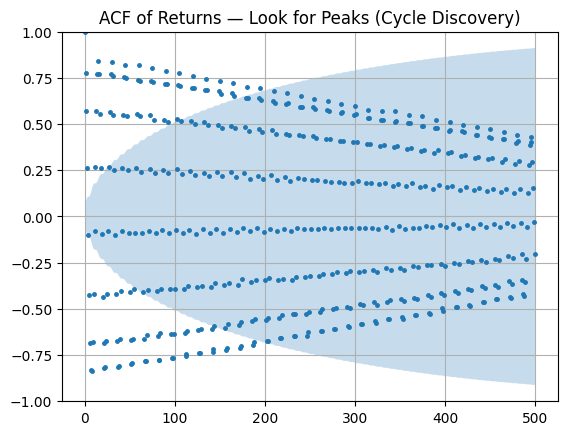

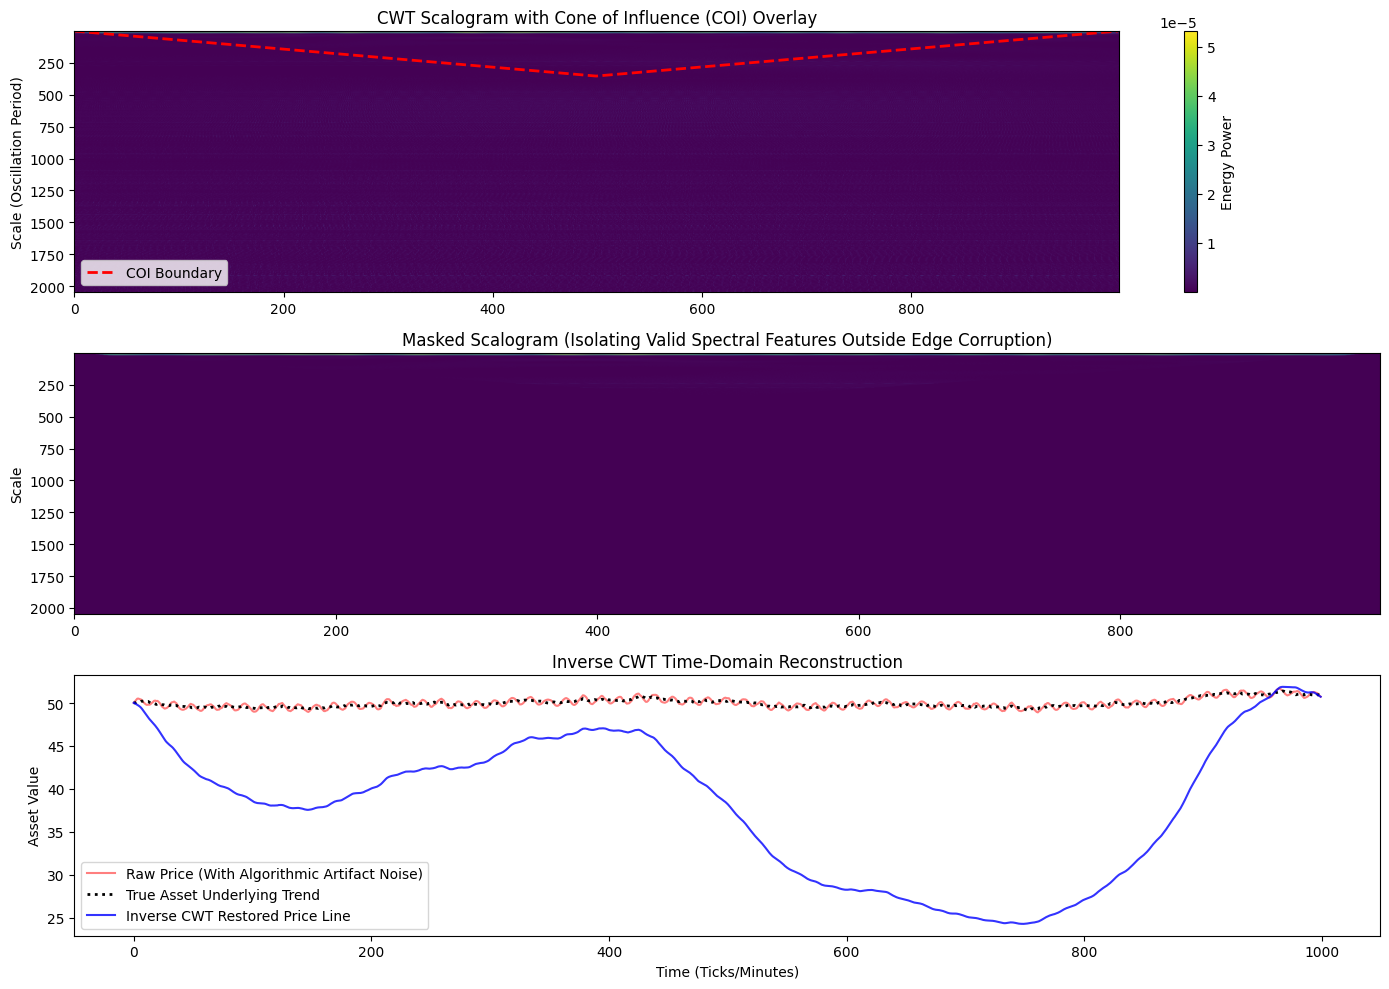

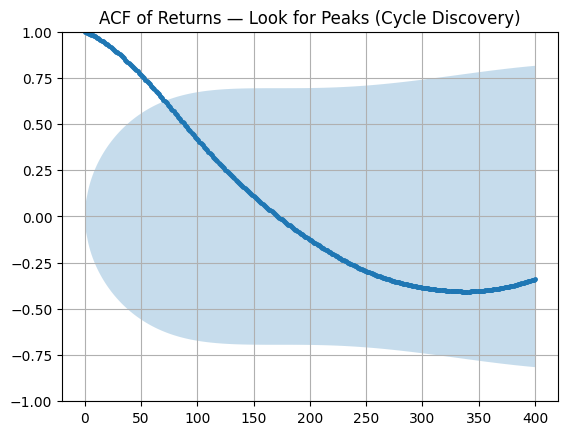

In [ ]:
def signal_cleaning(df=None,filter_bands=[(12,18)],len_to_analyze=1440):
    # ---------------------------------------------------------
    # 1. RAW SIGNAL GENERATION & STATIONARITY
    # ---------------------------------------------------------
    true_trend = None
    if df is None:
        np.random.seed(42)
        N = 1000
        time = np.arange(N)
        # Baseline clean asset trend
        true_trend = np.cumsum(np.random.normal(0, 0.05, size=N)) + 50.0
        # Inject localized high-frequency artifact (e.g., 15-minute crypto algorithmic loop)
        noise_artifact = 0.4 * np.sin(2 * np.pi * time / 15)
        raw_price = true_trend + noise_artifact
    else:
        #sandp data
        N = len_to_analyze
        raw_price = df["price"].values[:N]
    # Transform to log returns to stabilize variance for CWT input
    log_returns = np.diff(np.log(raw_price))
    N_sig = len(log_returns)    


    # -----------------------------
    # 1. Autocorrelation (ACF)
    # -----------------------------
    plot_acf(log_returns, lags=500,alpha=0.05,use_vlines=False,fft=True,marker='.')
    plt.title("ACF of Returns — Look for Peaks (Cycle Discovery)")
    # plt.ylim([-0.05,0.05])
    plt.grid(True)
    plt.show()

    # ---------------------------------------------------------
    # 2. FORWARD CONTINUOUS WAVELET TRANSFORM (CWT)
    # ---------------------------------------------------------
    scales = np.arange(2, 2048)
    # Use complex Morlet wavelet for optimal phase tracking
    cwt_matrix, frequencies = pywt.cwt(log_returns, scales, "cmor1.5-1.0")

    # ---------------------------------------------------------
    # 3. MATHEMATICAL IMPLEMENTATION: CONE OF INFLUENCE (COI)
    # ---------------------------------------------------------
    # For a Morlet wavelet, edge artifacts decay to e^-2 (13.5%) at a factor of sqrt(2) * scale
    coi_factor = np.sqrt(2)
    coi_boundary = np.zeros(N_sig)

    for t_idx in range(N_sig):
        # The distance to the nearest temporal boundary (left or right edge)
        edge_dist = min(t_idx, N_sig - 1 - t_idx)
        # The maximum uncorrupted scale at this point in time
        coi_boundary[t_idx] = edge_dist / coi_factor

    # Create a binary validity mask (1 = Clean Data, 0 = Edge Distortion)
    coi_mask = np.zeros_like(cwt_matrix, dtype=float)
    for s_idx, s_val in enumerate(scales):
        coi_mask[s_idx, :] = (s_val <= coi_boundary).astype(float)

    # ---------------------------------------------------------
    # 4. SIGNAL FILTERING (Erasing the 15-Min Wavelet Loop)
    # ---------------------------------------------------------
    # Target scale 15 and remove the noise anomaly safely inside the COI
    filtered_cwt = cwt_matrix.copy()
    for band in filter_bands:
        filtered_cwt[band[0]:band[1], :] = 0.0  # Nullify the 15-minute artifact band

    # ---------------------------------------------------------
    # 5. MATHEMATICAL IMPLEMENTATION: INVERSE CWT (iCWT)
    # ---------------------------------------------------------
    # Torrence & Compo Reconstruction: Real part of the sum of coefficients over scales
    # divided by the square root of the scales.
    reconstructed_returns = np.zeros(N_sig)
    for t_idx in range(N_sig):
        reconstructed_returns[t_idx] = np.sum(np.real(filtered_cwt[:, t_idx]) / np.sqrt(scales))

    # Normalize the scale reconstruction factor to match original input amplitude
    reconstructed_returns = (reconstructed_returns - np.mean(reconstructed_returns)) * (np.std(log_returns) / np.std(reconstructed_returns)) + np.mean(log_returns)

    # Reconstruct back to nominal price levels via cumulative exponential summing
    reconstructed_price = np.zeros(N)
    reconstructed_price[0] = raw_price[0]
    for i in range(1, N):
        reconstructed_price[i] = reconstructed_price[i-1] * np.exp(reconstructed_returns[i-1])

    # ---------------------------------------------------------
    # 6. SCIENTIFIC VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 10))

    # Subplot 1: Power Scalogram + COI Boundary Line
    plt.subplot(3, 1, 1)
    power = np.abs(cwt_matrix)**2
    plt.imshow(power, extent=[0, N_sig, scales[-1], scales[0]], cmap='viridis', aspect='auto')
    plt.plot(np.arange(N_sig), coi_boundary, color='red', linestyle='--', linewidth=2, label='COI Boundary')
    plt.title('CWT Scalogram with Cone of Influence (COI) Overlay')
    plt.ylabel('Scale (Oscillation Period)')
    plt.ylim(scales[-1], scales[0]) # Invert axis so large scales sit at the bottom
    plt.legend()
    plt.colorbar(label='Energy Power')

    # Subplot 2: Retained Data Inside the COI Window
    plt.subplot(3, 1, 2)
    plt.imshow(power * coi_mask, extent=[0, N_sig, scales[-1], scales[0]], cmap='viridis', aspect='auto')
    plt.title('Masked Scalogram (Isolating Valid Spectral Features Outside Edge Corruption)')
    plt.ylabel('Scale')
    plt.ylim(scales[-1], scales[0])

    # Subplot 3: Original vs. Cleaned Signal Price Line Reconstruction
    plt.subplot(3, 1, 3)
    plt.plot(raw_price, label='Raw Price (With Algorithmic Artifact Noise)', color='red', alpha=0.5)
    if true_trend is not None:
        plt.plot(true_trend, label='True Asset Underlying Trend', color='black', linestyle=':', linewidth=2)
    plt.plot(reconstructed_price, label='Inverse CWT Restored Price Line', color='blue', alpha=0.8)
    plt.title('Inverse CWT Time-Domain Reconstruction')
    plt.xlabel('Time (Ticks/Minutes)')
    plt.ylabel('Asset Value')
    plt.legend()

    plt.tight_layout()
    plt.show()

    plot_acf(reconstructed_price, lags=400,alpha=0.05,use_vlines=False,fft=True,marker='.')
    plt.title("ACF of Returns — Look for Peaks (Cycle Discovery)")
    # plt.ylim([-0.05,0.05])
    plt.grid(True)
    plt.show()
signal_cleaning(filter_bands=[(12,18)])

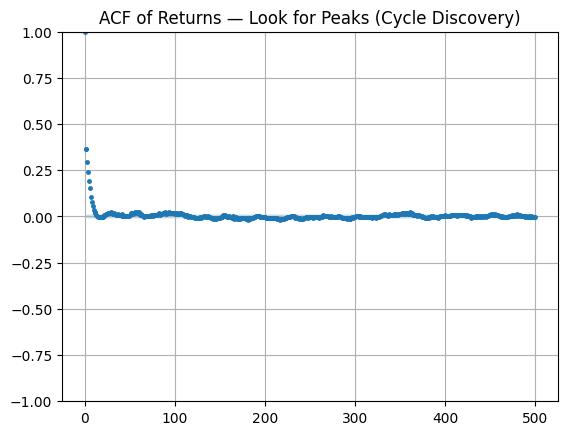

interruption: This cell was interrupted and needs to be re-run

In [ ]:
signal_cleaning(df_sandp,[(90,100)],len_to_analyze=770*90)

In [ ]:
def validate_MI():
    w_ref_local = np.arange(0,101)
    w_other = w_ref_local

    print(w_ref_local)
    print(w_other)

    for dt in [-5,-4,-3,-2,-1,0,1,2,3,4,5]:
    # Align time series depending on lag
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref_local[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref_local[:dt or None]

        print(dt)
        print(y)
        print(x)
validate_MI()   

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
-5
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 5

In [ ]:
-2
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98]
[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100]
2
[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98]